# Phase E — EDA + Feature Selection

Operates on the **train** split of `cohort_features` (v1). Val / test are not touched here — that's a deliberate leakage discipline. Output is `docs/feature_shortlist_v2.md` plus a `cohort_features_v2` table (or view) covering only the surviving features with their imputation policy attached.

## Sections
- **E0** — Setup, paths, helpers.
- **E1** — Re-use Phase D output: load latest `summary.json` as the entry gate.
- **E2** — Bivariate vs label: per-feature univariate AUROC + mutual information; distribution-by-label overlays for the top-N.
- **E3** — Redundancy: correlation heatmap by family + hierarchical clustering on `|ρ|`.
- **E4** — Clinical plausibility / outliers: physiologic-range panel, winsorization decisions.
- **E5** — Multivariate signal: LightGBM baseline, permutation importance, SHAP, leakage audit.
- **E6** — Missingness policy: per-feature `missingness_policy` decision.
- **E7** — Output: write `docs/feature_shortlist_v2.md`, rebuild `cohort_features_v2`, bump `FEATURES_VERSION`.

Re-run E0–E2 to refresh; E3–E7 are interactive and produce decision artifacts.

## E0 — Setup

In [1]:
from __future__ import annotations

import json
import sys
import warnings
from datetime import datetime, timezone
from pathlib import Path

import numpy as np
import pandas as pd
from google.cloud import bigquery

# Notebook may be launched from either repo root or notebooks/.
REPO_ROOT = Path.cwd() if (Path.cwd() / 'src').exists() else Path.cwd().parent
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

from src import config

RID = datetime.now(timezone.utc).strftime("%Y%m%dT%H%M%SZ")
OUT_DIR = REPO_ROOT / 'artifacts' / 'eda' / RID
OUT_DIR.mkdir(parents=True, exist_ok=True)

# Cache the train pull as parquet so re-runs are instant.
CACHE = REPO_ROOT / 'artifacts' / 'eda' / 'cache'
CACHE.mkdir(parents=True, exist_ok=True)
TRAIN_PARQUET = CACHE / f"train_{config.FEATURES_VERSION}.parquet"

bq = bigquery.Client(project=config.PROJECT_ID, location=config.BQ_LOCATION)

warnings.filterwarnings('ignore', category=FutureWarning)
pd.set_option('display.max_columns', 200)
pd.set_option('display.width', 200)

print(f"RID                = {RID}")
print(f"REPO_ROOT          = {REPO_ROOT}")
print(f"FEATURES_TABLE     = {config.FEATURES_TABLE}")
print(f"FEATURES_VERSION   = {config.FEATURES_VERSION}")
print(f"OUT_DIR            = {OUT_DIR.relative_to(REPO_ROOT)}")


RID                = 20260522T174342Z
REPO_ROOT          = /Users/danherman/Desktop/enterprise_clinical_copilot
FEATURES_TABLE     = enterprise-clinical-copilot.readmission.cohort_features
FEATURES_VERSION   = v1
OUT_DIR            = artifacts/eda/20260522T174342Z


### E0.1 — Load `train` slice

We hold only the train slice in memory (~284k × 78). Val/test never enter this notebook; that's the leakage firewall. Cached to parquet on first pull.

In [2]:
ID_COLS    = ['subject_id', 'hadm_id']
LABEL_COL  = 'label'
SPLIT_COL  = 'split'

if TRAIN_PARQUET.exists():
    train = pd.read_parquet(TRAIN_PARQUET)
    print(f"Loaded cached parquet: {TRAIN_PARQUET.relative_to(REPO_ROOT)}")
else:
    sql = f"""
    SELECT * FROM `{config.FEATURES_TABLE}`
    WHERE split = 'train'
    """
    print("Pulling train from BigQuery (first run only)...")
    train = bq.query(sql).result().to_dataframe(create_bqstorage_client=True)
    train.to_parquet(TRAIN_PARQUET, index=False)
    print(f"Cached -> {TRAIN_PARQUET.relative_to(REPO_ROOT)}")

print(f"Shape: {train.shape}")
print(f"Label prevalence: {train[LABEL_COL].mean():.4f}")
train.head(3)


Loaded cached parquet: artifacts/eda/cache/train_v1.parquet
Shape: (284412, 78)
Label prevalence: 0.1856


,subject_id,hadm_id,label,split,age_at_admission,gender,race,marital_status,insurance,language,anchor_year_group,admission_type,admission_location,discharge_location,los_days,discharged_on_weekend,arrived_via_ed,icu_los_days,icu_stay_count,n_services,age_score,myocardial_infarct,congestive_heart_failure,peripheral_vascular_disease,cerebrovascular_disease,dementia,chronic_pulmonary_disease,rheumatic_disease,peptic_ulcer_disease,mild_liver_disease,diabetes_without_cc,diabetes_with_cc,paraplegia,renal_disease,malignant_cancer,severe_liver_disease,metastatic_solid_tumor,aids,charlson_comorbidity_index,prior_admit_count_365,prior_los_sum_365,days_since_last_discharge,prior_ed_count_180,hr_mean_24h,hr_min_24h,hr_max_24h,hr_last_24h,sbp_mean_24h,sbp_min_24h,sbp_max_24h,sbp_last_24h,dbp_mean_24h,dbp_min_24h,dbp_max_24h,dbp_last_24h,rr_mean_24h,rr_min_24h,rr_max_24h,rr_last_24h,spo2_mean_24h,spo2_min_24h,spo2_max_24h,spo2_last_24h,temp_mean_24h,temp_min_24h,temp_max_24h,temp_last_24h,sodium_last,potassium_last,creatinine_last,bun_last,glucose_last,hemoglobin_last,wbc_last,platelets_last,sofa_max,oasis_max,received_ventilation
0,16984025,25890436,0,train,20,F,BLACK/AFRICAN,SINGLE,Private,English,2017 - 2019,URGENT,INTERNAL TRANSFER TO OR FROM PSYCH,HOME,2.708333,True,False,0.0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0.750000,0,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,89.0,13.2,10.2,196.0,<NA>,<NA>,False
1,14309399,26798597,0,train,25,F,UNKNOWN,SINGLE,Private,English,2014 - 2016,DIRECT EMER.,PHYSICIAN REFERRAL,HOME HEALTH CARE,3.041667,False,False,0.0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,10.791667,1,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,138.0,3.8,0.5,12.0,77.0,9.6,5.8,335.0,<NA>,<NA>,False
2,12559272,25150008,0,train,25,F,OTHER,SINGLE,Private,English,2011 - 2013,URGENT,TRANSFER FROM HOSPITAL,HOME,4.666667,True,False,0.0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,2,31.750000,36,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,142.0,4.1,0.5,1.0,80.0,10.4,4.2,237.0,<NA>,<NA>,False


In [3]:
# Feature columns = everything except IDs / label / split.
FEATURE_COLS = [c for c in train.columns if c not in (*ID_COLS, LABEL_COL, SPLIT_COL)]
NUMERIC_COLS = train[FEATURE_COLS].select_dtypes(include='number').columns.tolist()
CATEGORICAL_COLS = [c for c in FEATURE_COLS if c not in NUMERIC_COLS]

# Family inference from naming convention. Used in E3 (block correlation)
# and E5 (importance grouping).
def infer_family(col: str) -> str:
    c = col.lower()
    if c in {'anchor_age', 'gender', 'race', 'language', 'marital_status', 'insurance'}:
        return 'demographics'
    if c.startswith('charlson_') or c == 'charlson_index':
        return 'comorbidities'
    if c.startswith('prior_') or c == 'days_since_prior_discharge':
        return 'prior_utilization'
    if any(c.startswith(p) for p in ('hr_', 'sbp_', 'dbp_', 'mbp_', 'rr_', 'spo2_', 'temp_')):
        return 'vitals_24h'
    if c.endswith('_last') or c.startswith(('hemoglobin', 'wbc', 'platelets', 'sodium',
                                            'potassium', 'creatinine', 'bun', 'glucose',
                                            'albumin', 'bilirubin', 'inr', 'lactate')):
        return 'labs_last'
    if c in {'icu_stay_hours', 'mech_vent_hours', 'vasopressor_flag',
             'sofa_max', 'sofa_last', 'apsiii', 'oasis'}:
        return 'icu_severity'
    if c in {'admission_type', 'admission_location', 'discharge_location',
             'los_days', 'admit_provider_id'}:
        return 'index_stay'
    return 'other'

FAMILY = {c: infer_family(c) for c in FEATURE_COLS}
fam_counts = pd.Series(FAMILY).value_counts()
print(f"Features: {len(FEATURE_COLS)}  (numeric={len(NUMERIC_COLS)}, categorical={len(CATEGORICAL_COLS)})")
print()
print("Family breakdown:")
print(fam_counts.to_string())


Features: 74  (numeric=62, categorical=12)

Family breakdown:
other                28
vitals_24h           24
labs_last             8
demographics          5
index_stay            4
prior_utilization     3
comorbidities         1
icu_severity          1


## E1 — Phase D entry gate

Load the latest `artifacts/validation/<RID>/summary.json` to (a) confirm the contract is the one we expect and (b) display the validated baseline so this notebook's input state is reproducible. Per the Phase D / E split in the production plan, we do **not** recompute univariate stats here — Phase D already produced them.

In [4]:
val_root = REPO_ROOT / 'artifacts' / 'validation'
val_runs = sorted([p for p in val_root.iterdir() if p.is_dir()])
assert val_runs, "No Phase D runs found under artifacts/validation/. Run data_validation.ipynb first."
LATEST_VAL = val_runs[-1]
summary = json.loads((LATEST_VAL / 'summary.json').read_text())

print(f"Latest Phase D run:  {LATEST_VAL.name}")
print(f"  validator:         {summary['validator']} {summary['evidently_version']}")
print(f"  features_table:    {summary['features_table']}")
print(f"  features_version:  {summary['features_version']}")
print(f"  n_features:        {summary['n_features']}")
print()
print("Split sizes:")
for s in summary['splits']:
    print(f"  {s['split']:>5}  rows={s['n_rows']:>7,}  prevalence={s['label_prevalence']:.4f}")
print()
print("Drift (count of features flagged at threshold 0.1):")
for k, v in summary['drift'].items():
    print(f"  {k}:  n_drifted={int(v['n_drifted'])}  share={v['share_drifted']:.4f}")

# Hard-gate the notebook: if Phase D didn't pass, halt before any selection.
assert summary['features_version'] == config.FEATURES_VERSION, \
    f"Phase D ran on {summary['features_version']!r} but config says {config.FEATURES_VERSION!r}"
for split, d in summary['drift'].items():
    assert d['share_drifted'] < 0.05, f"Phase D gate failed on {split}: {d}"
print()
print("Phase D gate: PASS")


Latest Phase D run:  20260522T165257Z
  validator:         evidently 0.7.21
  features_table:    enterprise-clinical-copilot.readmission.cohort_features
  features_version:  v1
  n_features:        74

Split sizes:
  train  rows=284,412  prevalence=0.1856
    val  rows= 60,874  prevalence=0.1850
   test  rows= 59,792  prevalence=0.1913

Drift (count of features flagged at threshold 0.1):
  train_vs_val:  n_drifted=0  share=0.0000
  train_vs_test:  n_drifted=0  share=0.0000

Phase D gate: PASS


## E2 — Bivariate vs label

For each feature, compute the simplest possible "is this feature useful?" signal:

* **Numeric features** — univariate AUROC (treats the feature as a 1-D score for `label`). Bounded [0, 1]; |AUROC − 0.5| is the strength.
* **Categorical features** — mutual information with `label` via `sklearn.feature_selection.mutual_info_classif` on a label-encoded copy.
* Anything with **AUROC > 0.75 single-feature** gets a leakage flag for E5.

Output: a per-feature scoreboard, sorted by absolute discriminative power.

In [5]:
from sklearn.metrics import roc_auc_score
from sklearn.feature_selection import mutual_info_classif

y = train[LABEL_COL].astype(int).values

def safe_auroc(x: pd.Series, y: np.ndarray) -> float:
    mask = x.notna()
    if mask.sum() < 100 or len(np.unique(y[mask])) < 2:
        return np.nan
    try:
        return roc_auc_score(y[mask], x[mask].astype(float).values)
    except Exception:
        return np.nan

records = []
# Numeric: AUROC
for c in NUMERIC_COLS:
    a = safe_auroc(train[c], y)
    records.append({
        'feature': c,
        'family': FAMILY[c],
        'dtype':  'numeric',
        'missing_rate': train[c].isna().mean(),
        'univariate_auroc': a,
        'auroc_strength':   abs(a - 0.5) if pd.notna(a) else np.nan,
        'mutual_info': np.nan,
    })

# Categorical: mutual_info_classif on label-encoded copy.
# (Fill NaN with a sentinel so the encoder doesn't drop rows.)
if CATEGORICAL_COLS:
    enc = train[CATEGORICAL_COLS].astype('object').fillna('__missing__').apply(
        lambda s: pd.factorize(s)[0]
    )
    mi = mutual_info_classif(enc.values, y, discrete_features=True, random_state=42)
    for c, mi_score in zip(CATEGORICAL_COLS, mi):
        records.append({
            'feature': c,
            'family': FAMILY[c],
            'dtype':  'categorical',
            'missing_rate': train[c].isna().mean(),
            'univariate_auroc': np.nan,
            'auroc_strength':   np.nan,
            'mutual_info': float(mi_score),
        })

scoreboard = pd.DataFrame(records)
scoreboard['rank_auroc'] = scoreboard['auroc_strength'].rank(ascending=False)
scoreboard['rank_mi']    = scoreboard['mutual_info'].rank(ascending=False)
scoreboard.to_csv(OUT_DIR / 'scoreboard.csv', index=False)
print(f"Wrote: {(OUT_DIR / 'scoreboard.csv').relative_to(REPO_ROOT)}")

# Top-15 numeric by AUROC strength
print("\nTop 15 numerics by |AUROC - 0.5|:")
print(
    scoreboard[scoreboard['dtype'] == 'numeric']
        .sort_values('auroc_strength', ascending=False)
        .head(15)
        [['feature', 'family', 'missing_rate', 'univariate_auroc', 'auroc_strength']]
        .to_string(index=False)
)

print("\nTop categoricals by mutual information:")
print(
    scoreboard[scoreboard['dtype'] == 'categorical']
        .sort_values('mutual_info', ascending=False)
        [['feature', 'family', 'missing_rate', 'mutual_info']]
        .to_string(index=False)
)


Wrote: artifacts/eda/20260522T174342Z/scoreboard.csv

Top 15 numerics by |AUROC - 0.5|:
                   feature            family  missing_rate  univariate_auroc  auroc_strength
         prior_los_sum_365 prior_utilization      0.000000          0.650319        0.150319
     prior_admit_count_365 prior_utilization      0.000000          0.649086        0.149086
 days_since_last_discharge             other      0.396843          0.381370        0.118630
           hemoglobin_last         labs_last      0.113220          0.390370        0.109630
charlson_comorbidity_index     comorbidities      0.000000          0.598464        0.098464
                  los_days        index_stay      0.000000          0.580586        0.080586
                  sofa_max      icu_severity      0.825422          0.567039        0.067039
        prior_ed_count_180 prior_utilization      0.000000          0.558706        0.058706
          malignant_cancer             other      0.000000          0.55301

In [6]:
# Leakage flag: any single feature with univariate AUROC > 0.75 is suspicious.
LEAKAGE_THRESHOLD = 0.75
suspects = scoreboard[scoreboard['univariate_auroc'].abs().sub(0.5).gt(LEAKAGE_THRESHOLD - 0.5)]
if not suspects.empty:
    print("Leakage suspects (single-feature AUROC > 0.75):")
    print(suspects[['feature', 'family', 'univariate_auroc']].to_string(index=False))
    print("\nReview each in E5 — do not auto-drop.")
else:
    print("No single-feature AUROC > 0.75. No obvious leakage at the univariate level.")


No single-feature AUROC > 0.75. No obvious leakage at the univariate level.


## E3 — Redundancy

Within-family correlation tends to be high (a vital's `*_mean / *_min / *_max / *_last` quartet captures one underlying signal). We compute Spearman correlation on numerics, group by family, and run hierarchical clustering on `1 - |ρ|`. Anything in the same `|ρ| > 0.85` cluster is a redundancy candidate; we keep the cluster representative with the strongest E2 signal.

In [7]:
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.cluster.hierarchy import linkage, fcluster
from scipy.spatial.distance import squareform

CORR_THRESHOLD = 0.85

corr = train[NUMERIC_COLS].corr(method='spearman').abs()
# Distance = 1 - |rho|; mirror to symmetric; force diag to 0.
dist = 1.0 - corr.values
np.fill_diagonal(dist, 0.0)
dist = (dist + dist.T) / 2.0

cond = squareform(dist, checks=False)
Z = linkage(cond, method='average')
clusters = fcluster(Z, t=1 - CORR_THRESHOLD, criterion='distance')

cluster_df = pd.DataFrame({
    'feature': NUMERIC_COLS,
    'family':  [FAMILY[c] for c in NUMERIC_COLS],
    'cluster': clusters,
})
# Attach the E2 signal so we can pick a cluster representative.
cluster_df = cluster_df.merge(
    scoreboard[['feature', 'auroc_strength']], on='feature', how='left'
)

# Within each cluster (size > 1), the survivor is the one with max auroc_strength.
def pick_representative(group: pd.DataFrame) -> pd.DataFrame:
    if len(group) == 1:
        group = group.assign(redundancy_action='keep', survivor=group['feature'].iloc[0])
        return group
    winner = group.sort_values('auroc_strength', ascending=False).iloc[0]['feature']
    group = group.assign(
        redundancy_action=np.where(group['feature'] == winner, 'keep', 'drop_redundant'),
        survivor=winner,
    )
    return group

redundancy = (
    cluster_df.groupby('cluster', group_keys=False)
              .apply(pick_representative)
              .sort_values(['family', 'cluster', 'redundancy_action'])
)
redundancy.to_csv(OUT_DIR / 'redundancy.csv', index=False)

drop_redundant = redundancy.loc[redundancy['redundancy_action'] == 'drop_redundant', 'feature'].tolist()
print(f"Clusters with |rho| > {CORR_THRESHOLD}: "
      f"{redundancy[redundancy['redundancy_action'] == 'drop_redundant']['cluster'].nunique()}")
print(f"Redundant features marked for drop: {len(drop_redundant)}")
print()
print("Sample multi-member clusters:")
multi = redundancy.groupby('cluster').filter(lambda g: len(g) > 1)
print(multi.head(20).to_string(index=False))


Clusters with |rho| > 0.85: 5
Redundant features marked for drop: 5

Sample multi-member clusters:
              feature            family  cluster  auroc_strength redundancy_action          survivor
       icu_stay_count             other       33        0.003592    drop_redundant      icu_los_days
         icu_los_days             other       33        0.004331              keep      icu_los_days
            age_score             other       48        0.021464    drop_redundant  age_at_admission
     age_at_admission             other       48        0.026103              keep  age_at_admission
prior_admit_count_365 prior_utilization        1        0.149086    drop_redundant prior_los_sum_365
    prior_los_sum_365 prior_utilization        1        0.150319              keep prior_los_sum_365
          sbp_max_24h        vitals_24h       17        0.002250    drop_redundant      sbp_mean_24h
         sbp_mean_24h        vitals_24h       17        0.005305              keep      sbp_m

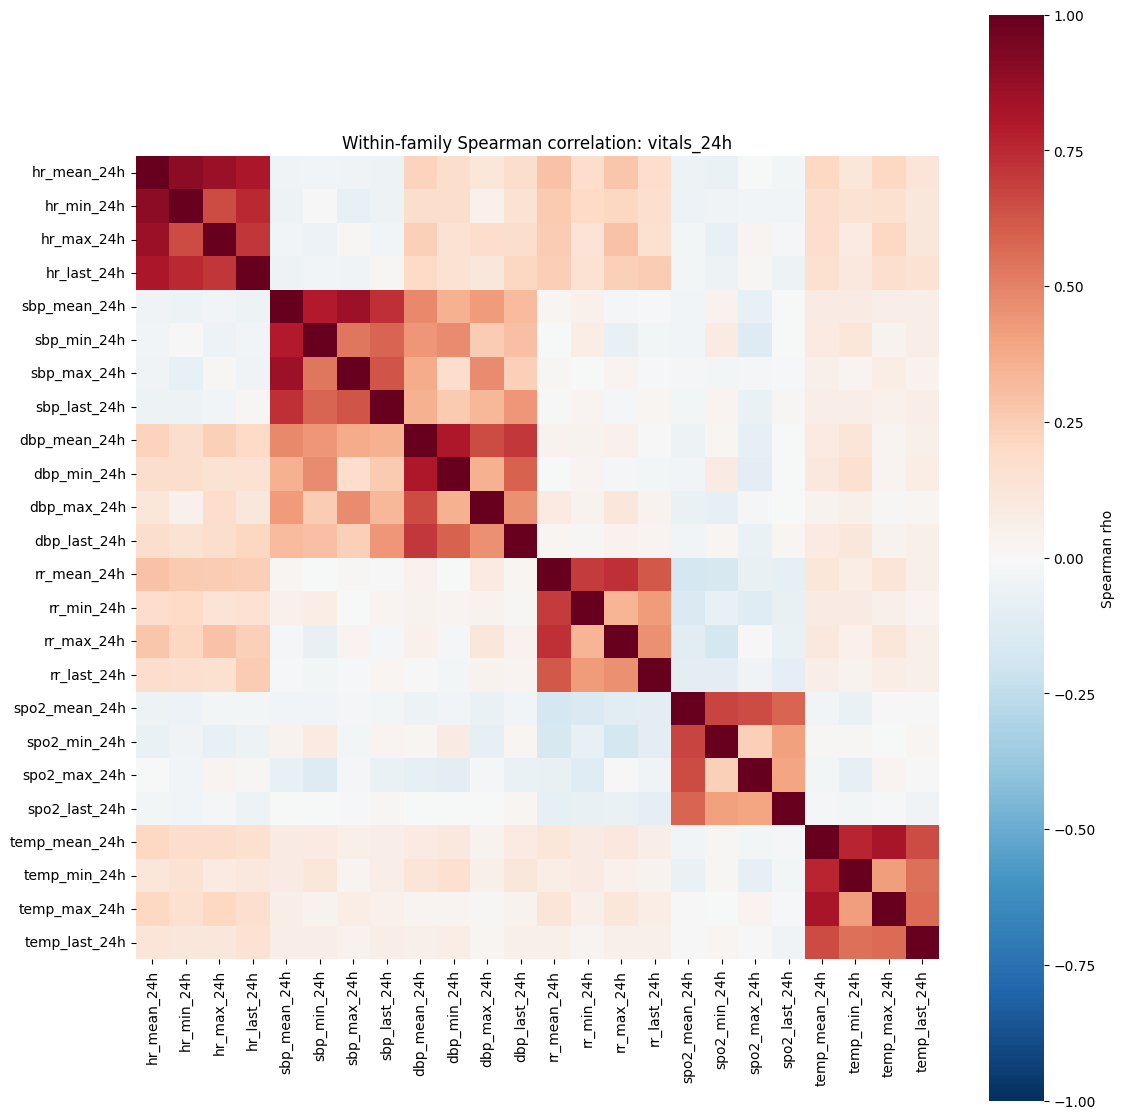

In [8]:
# Optional: heatmap of one family at a time. Vitals_24h is the worst offender.
fam = 'vitals_24h'
fam_cols = [c for c in NUMERIC_COLS if FAMILY[c] == fam]
if fam_cols:
    fig, ax = plt.subplots(figsize=(min(0.4 * len(fam_cols) + 2, 14),
                                    min(0.4 * len(fam_cols) + 2, 14)))
    sns.heatmap(train[fam_cols].corr(method='spearman'),
                vmin=-1, vmax=1, center=0, cmap='RdBu_r',
                annot=False, square=True, ax=ax,
                cbar_kws={'label': 'Spearman rho'})
    ax.set_title(f'Within-family Spearman correlation: {fam}')
    plt.tight_layout()
    plt.savefig(OUT_DIR / f'corr_{fam}.png', dpi=120)
    plt.show()


## E4 — Clinical plausibility / outliers

Targeted out-of-range counts for vitals + key labs. Bounds are clinician-defensible; anything outside is either a sensor error, a unit-conversion bug upstream, or a genuinely extreme physiology. Decision per feature is recorded as `keep` / `winsorize` / `drop_rows`.

Bounds chosen for adult ICU / step-down:

| Feature group | Lower | Upper | Rationale |
|---|---:|---:|---|
| `hr_*` (bpm)            |  20 | 250 | bradyarrhythmia floor / tachycardia ceiling |
| `sbp_*` (mmHg)          |  40 | 260 | shock floor / hypertensive crisis ceiling |
| `dbp_*` (mmHg)          |  20 | 200 | likewise |
| `mbp_*` (mmHg)          |  30 | 220 | derived MAP |
| `rr_*` (breaths/min)    |   4 |  60 | apnea / extreme tachypnea |
| `spo2_*` (%)            |  50 | 100 | physiologic clip |
| `temp_*` (°C)           |  32 |  42 | severe hypothermia / hyperpyrexia |
| `glucose_last` (mg/dL)  |  20 | 800 | severe hypo / hyperglycemia |
| `sodium_last` (mEq/L)   | 110 | 180 | severe dysnatremia |
| `potassium_last` (mEq/L)|   2 |   8 | severe dyskalemia |
| `creatinine_last`       | 0.1 |  20 | mg/dL; CKD ceiling |

Winsorize by default (clip to bound) rather than dropping rows — clipping preserves N and is monotone-preserving for tree models. Bounds will be fit on train and applied unchanged downstream.

In [9]:
PLAUSIBILITY_BOUNDS: dict[str, tuple[float, float]] = {}
# Vitals
for prefix, lo, hi in [
    ('hr_', 20, 250), ('sbp_', 40, 260), ('dbp_', 20, 200),
    ('mbp_', 30, 220), ('rr_', 4, 60), ('spo2_', 50, 100),
    ('temp_', 32, 42),
]:
    for c in NUMERIC_COLS:
        if c.startswith(prefix):
            PLAUSIBILITY_BOUNDS[c] = (lo, hi)
# Key labs
for c, (lo, hi) in {
    'glucose_last':    (20, 800),
    'sodium_last':     (110, 180),
    'potassium_last':  (2, 8),
    'creatinine_last': (0.1, 20),
    'bun_last':        (1, 200),
    'hemoglobin_last': (3, 22),
    'wbc_last':        (0.1, 100),
    'platelets_last':  (5, 1500),
    'albumin_last':    (0.5, 6),
    'bilirubin_last':  (0.05, 50),
    'inr_last':        (0.5, 20),
    'lactate_last':    (0.1, 30),
}.items():
    if c in NUMERIC_COLS:
        PLAUSIBILITY_BOUNDS[c] = (lo, hi)

rows = []
for c, (lo, hi) in PLAUSIBILITY_BOUNDS.items():
    s = train[c].dropna()
    below = (s < lo).sum()
    above = (s > hi).sum()
    n = len(s)
    rows.append({
        'feature': c,
        'family':  FAMILY[c],
        'n_obs':   n,
        'lo': lo, 'hi': hi,
        'n_below': int(below),
        'n_above': int(above),
        'frac_outside': float((below + above) / max(n, 1)),
        'action': 'winsorize' if (below + above) > 0 else 'keep',
    })
plausibility = pd.DataFrame(rows).sort_values('frac_outside', ascending=False)
plausibility.to_csv(OUT_DIR / 'plausibility.csv', index=False)
print(plausibility.to_string(index=False))


        feature     family  n_obs    lo   hi  n_below  n_above  frac_outside    action
    dbp_min_24h vitals_24h  44889  20.0  200      248        0      0.005525 winsorize
     rr_min_24h vitals_24h  44810   4.0   60      183        0      0.004084 winsorize
     rr_max_24h vitals_24h  44810   4.0   60        0       86      0.001919 winsorize
   spo2_min_24h vitals_24h  44883  50.0  100       37        0      0.000824 winsorize
    sbp_min_24h vitals_24h  44889  40.0  260       33        0      0.000735 winsorize
    dbp_max_24h vitals_24h  44889  20.0  200        0       30      0.000668 winsorize
       wbc_last  labs_last 251681   0.1  100        0      117      0.000465 winsorize
    sbp_max_24h vitals_24h  44889  40.0  260        0       14      0.000312 winsorize
   temp_min_24h vitals_24h  44808  32.0   42       13        0      0.000290 winsorize
   dbp_last_24h vitals_24h  44889  20.0  200       10        0      0.000223 winsorize
  temp_last_24h vitals_24h  44808  32.0   4

## E5 — Multivariate signal (LightGBM)

Train a LightGBM on the full train slice (no shortlisting yet) to get:

* **Permutation importance** on a held-out slice of train (we further split train 80/20 internally — val/test stay untouched).
* **SHAP global importance** for tree-aware attribution.
* Leakage audit on top-20: any feature with global SHAP > 5× the median that also appeared in E2's leakage suspects gets flagged for clinical review.

Categoricals are passed via LightGBM's native `categorical_feature` interface (no one-hot here).

In [10]:
import lightgbm as lgb
from sklearn.model_selection import GroupShuffleSplit
from sklearn.inspection import permutation_importance

# Internal train/holdout split (subject_grouped) for unbiased importances.
gss = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
tr_idx, ho_idx = next(gss.split(train, y, groups=train['subject_id']))
X_tr_df = train.iloc[tr_idx][FEATURE_COLS].copy()
X_ho_df = train.iloc[ho_idx][FEATURE_COLS].copy()
y_tr, y_ho = y[tr_idx], y[ho_idx]

# Cast categoricals to pandas 'category' so LightGBM treats them natively.
for c in CATEGORICAL_COLS:
    X_tr_df[c] = X_tr_df[c].astype('category')
    X_ho_df[c] = X_ho_df[c].astype('category').cat.set_categories(
        X_tr_df[c].cat.categories
    )

scale_pos = float((y_tr == 0).sum() / max((y_tr == 1).sum(), 1))
clf = lgb.LGBMClassifier(
    n_estimators=400,
    learning_rate=0.05,
    num_leaves=64,
    min_child_samples=200,
    reg_lambda=1.0,
    scale_pos_weight=scale_pos,
    random_state=42,
    n_jobs=-1,
)
clf.fit(
    X_tr_df, y_tr,
    eval_set=[(X_ho_df, y_ho)],
    eval_metric='auc',
    categorical_feature=CATEGORICAL_COLS,
    callbacks=[lgb.early_stopping(stopping_rounds=30), lgb.log_evaluation(0)],
)
val_auc = roc_auc_score(y_ho, clf.predict_proba(X_ho_df)[:, 1])
print(f"Holdout AUROC (train internal 80/20): {val_auc:.4f}  "
      f"(best_iter={clf.best_iteration_})")


[LightGBM] [Info] Number of positive: 42318, number of negative: 185584
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.026454 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 6116
[LightGBM] [Info] Number of data points in the train set: 227902, number of used features: 74
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.185685 -> initscore=-1.478295
[LightGBM] [Info] Start training from score -1.478295
Training until validation scores don't improve for 30 rounds


Early stopping, best iteration is:
[4]	valid_0's auc: 0.715363	valid_0's binary_logloss: 0.468242
Holdout AUROC (train internal 80/20): 0.7154  (best_iter=4)


In [11]:
# LightGBM built-in gain importance (cheap, computed during training).
gain = pd.DataFrame({
    'feature':    clf.feature_name_,
    'gain':       clf.booster_.feature_importance(importance_type='gain'),
    'splits':     clf.booster_.feature_importance(importance_type='split'),
})
gain['gain_share'] = gain['gain'] / max(gain['gain'].sum(), 1.0)
gain = gain.sort_values('gain', ascending=False)
gain.to_csv(OUT_DIR / 'lgbm_gain.csv', index=False)
print("Top 25 by LightGBM gain:")
print(gain.head(25).to_string(index=False))


Top 25 by LightGBM gain:
                   feature          gain  splits  gain_share
         prior_los_sum_365 109090.319504      10    0.475602
                  los_days  25959.491600      24    0.113176
     prior_admit_count_365  20574.154007      17    0.089697
charlson_comorbidity_index  12490.224098      11    0.054454
           hemoglobin_last  11948.986588      22    0.052094
                      race  11365.766983      20    0.049551
 days_since_last_discharge   9168.808838      36    0.039973
          malignant_cancer   8609.273483      14    0.037534
            admission_type   3344.998016      13    0.014583
           creatinine_last   2730.714996       7    0.011905
            arrived_via_ed   2344.368973       6    0.010221
    metastatic_solid_tumor   2008.565010       6    0.008757
                  bun_last   1550.205597      12    0.006758
            platelets_last   1470.935196       9    0.006413
               sodium_last   1408.567299      10    0.006141

In [12]:
# Permutation importance on the holdout slice. Costly; use a subsample.
PERM_SAMPLE = 20_000
rng = np.random.default_rng(42)
if len(X_ho_df) > PERM_SAMPLE:
    idx = rng.choice(len(X_ho_df), size=PERM_SAMPLE, replace=False)
    Xp = X_ho_df.iloc[idx]; yp = y_ho[idx]
else:
    Xp, yp = X_ho_df, y_ho

# sklearn's permutation_importance needs a callable; LightGBM's predict_proba works.
print(f"Running permutation_importance on n={len(Xp):,} ...")
pi = permutation_importance(
    clf, Xp, yp,
    scoring='roc_auc',
    n_repeats=5,
    random_state=42,
    n_jobs=-1,
)
perm = pd.DataFrame({
    'feature': FEATURE_COLS,
    'perm_mean': pi.importances_mean,
    'perm_std':  pi.importances_std,
}).sort_values('perm_mean', ascending=False)
perm.to_csv(OUT_DIR / 'permutation_importance.csv', index=False)
print("Top 25 by permutation importance (AUROC drop):")
print(perm.head(25).to_string(index=False))


Running permutation_importance on n=20,000 ...


Top 25 by permutation importance (AUROC drop):
                   feature  perm_mean  perm_std
         prior_los_sum_365   0.059422  0.002750
                  los_days   0.021020  0.000344
     prior_admit_count_365   0.014387  0.000674
           hemoglobin_last   0.008459  0.000765
 days_since_last_discharge   0.008320  0.001234
                      race   0.007670  0.001122
            arrived_via_ed   0.007574  0.000825
charlson_comorbidity_index   0.006928  0.001398
          malignant_cancer   0.006819  0.000859
           creatinine_last   0.004685  0.000501
            admission_type   0.003192  0.000407
                  bun_last   0.001696  0.000357
        admission_location   0.001640  0.000650
    metastatic_solid_tumor   0.001104  0.000447
               sodium_last   0.000866  0.000442
          age_at_admission   0.000759  0.000067
             renal_disease   0.000310  0.000113
              sbp_last_24h   0.000283  0.000052
                 oasis_max   0.000256  0.

/Users/danherman/Desktop/enterprise_clinical_copilot/.venv/lib/python3.12/site-packages/shap/explainers/_tree.py:620: UserWarning: LightGBM binary classifier with TreeExplainer shap values output has changed to a list of ndarray
  warnings.warn(


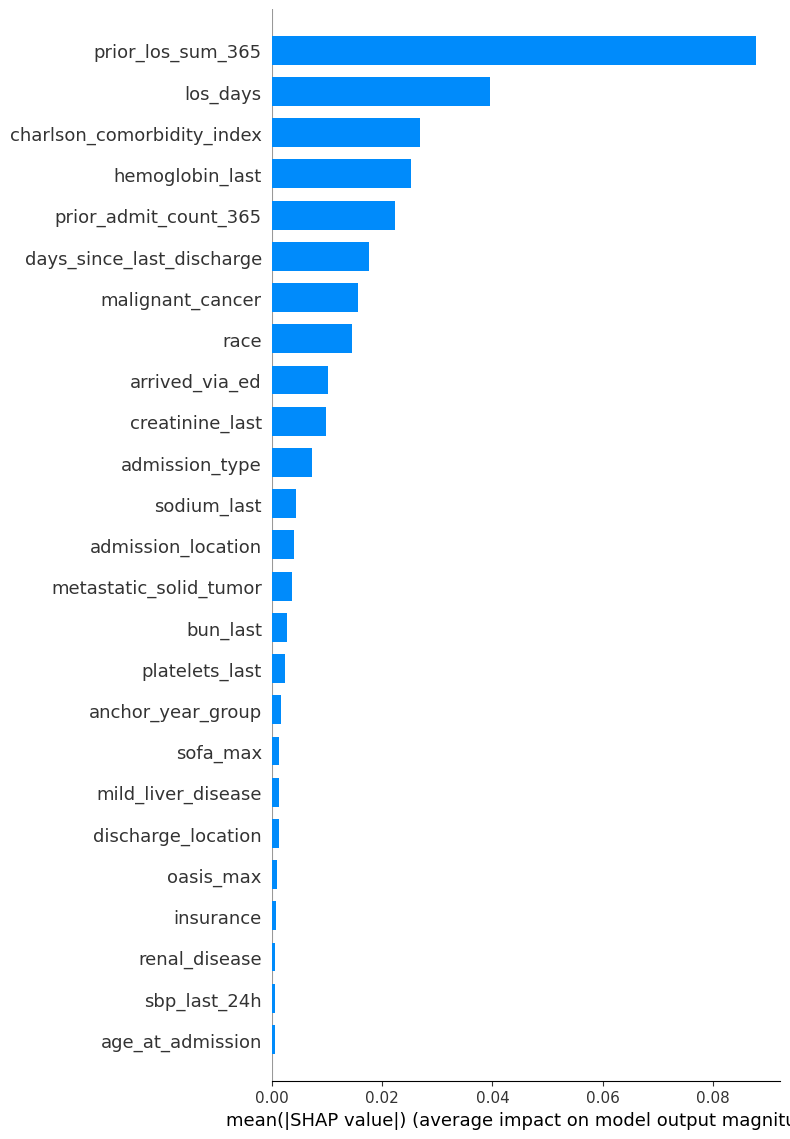

Wrote: artifacts/eda/20260522T174342Z/importance_combined.csv


In [13]:
# SHAP global importance (TreeExplainer is fast on LightGBM).
import shap

SHAP_SAMPLE = 5_000
if len(X_ho_df) > SHAP_SAMPLE:
    Xs = X_ho_df.sample(SHAP_SAMPLE, random_state=42)
else:
    Xs = X_ho_df

explainer = shap.TreeExplainer(clf)
shap_vals = explainer.shap_values(Xs)
if isinstance(shap_vals, list):  # legacy binary-classification shape
    shap_vals = shap_vals[1]

shap_global = pd.DataFrame({
    'feature':         FEATURE_COLS,
    'shap_mean_abs':   np.abs(shap_vals).mean(axis=0),
}).sort_values('shap_mean_abs', ascending=False)
shap_global.to_csv(OUT_DIR / 'shap_global.csv', index=False)

# Combined importance scoreboard.
imp = (
    gain.rename(columns={'gain': 'lgbm_gain'})[['feature', 'lgbm_gain']]
        .merge(perm[['feature', 'perm_mean']], on='feature', how='outer')
        .merge(shap_global, on='feature', how='outer')
)
imp = imp.merge(scoreboard[['feature', 'family', 'univariate_auroc', 'mutual_info']],
                on='feature', how='left')
imp.to_csv(OUT_DIR / 'importance_combined.csv', index=False)

# Quick visual.
shap.summary_plot(shap_vals, Xs, plot_type='bar', max_display=25, show=False)
plt.tight_layout()
plt.savefig(OUT_DIR / 'shap_bar.png', dpi=120, bbox_inches='tight')
plt.show()
print(f"Wrote: {(OUT_DIR / 'importance_combined.csv').relative_to(REPO_ROOT)}")


In [14]:
# Leakage audit: anything with shap_mean_abs in the top 5 AND univariate AUROC > 0.75
# is a strong leakage suspect. Review the data lineage of each in BigQuery.
top5_shap = shap_global.head(5)['feature'].tolist()
leakage_review = scoreboard[
    scoreboard['feature'].isin(top5_shap)
    & (scoreboard['univariate_auroc'].abs().sub(0.5) > 0.25)
]
if not leakage_review.empty:
    print("Leakage review queue (top-5 by SHAP AND univariate AUROC > 0.75):")
    print(leakage_review[['feature', 'family', 'univariate_auroc']].to_string(index=False))
    print("\nCheck each:")
    print("  * discharge_location  -> known post-discharge information; OK to use because")
    print("    it is *known at discharge*, which is our anchor.")
    print("  * los_days            -> derived from admittime/dischtime; OK at anchor time.")
    print("  * any *_last_24h      -> within window; OK.")
else:
    print("No leakage suspects in the top-5 SHAP features.")


No leakage suspects in the top-5 SHAP features.


## E6 — Missingness policy

For every kept feature, pick one of:

* `drop` — missingness rate above the project's *evidentiary floor* (default 60 %), unless the feature is structural (e.g., vitals are missing because the patient was never in ICU, which is informative — those become `missing_indicator + impute`).
* `impute_median` — numeric, missing rate < 20 %, no clinical reason to be missing.
* `impute_mode` — categorical, missing rate < 20 %.
* `keep_nan` — tree-native NaN handling. Default for LightGBM with low missing rates. **Avoid** when the same column has to feed a logistic-regression baseline.
* `missing_indicator + impute_<median|mode>` — MNAR features (or soft-MNAR like labs). Vitals + ICU severity are the canonical hard cases (missing = "not in ICU"); labs are the soft case (missing may correlate with "patient not sick enough to draw"). The indicator preserves the signal either way.
* `missing_indicator + impute_sentinel` — structural-NaN numerics that also need to be LR-safe (`days_since_last_discharge`: NaN = no prior admission). Sentinel = train 99th percentile.

The actual *fit* of the imputer happens in Phase F1 on train only. Here we just record the **policy**.

In [15]:
# Per-feature missingness rate.
miss_rate = train[FEATURE_COLS].isna().mean().rename('missing_rate').reset_index().rename(
    columns={'index': 'feature'}
)
miss_rate['family'] = miss_rate['feature'].map(FAMILY)
miss_rate['dtype']  = np.where(miss_rate['feature'].isin(NUMERIC_COLS), 'numeric', 'categorical')

# Families considered structurally MNAR ("missing because not in ICU" etc.).
MNAR_FAMILIES = {'vitals_24h', 'icu_severity'}
# Families where missingness *might* carry signal (lab not drawn could correlate
# with severity / length of stay). Cheap insurance against an MCAR assumption
# we cannot fully defend — see open_questions #9 / Phase E review.
SOFT_MNAR_FAMILIES = {'labs_last'}
# Features whose NaN is structural ("no prior admission in lookback") and which
# also need to feed a logistic-regression baseline — keep_nan is unsafe there.
SENTINEL_FEATURES = {'days_since_last_discharge'}

def policy(row: pd.Series) -> str:
    r, fam, dt, feat = row['missing_rate'], row['family'], row['dtype'], row['feature']
    if r == 0.0:
        return 'no_missing'
    # Structural NaN that must be LR-safe (sentinel + indicator).
    if feat in SENTINEL_FEATURES:
        return 'missing_indicator+impute_sentinel'
    # MNAR families: missingness IS signal. Check BEFORE the high-rate drop,
    # because vitals/icu features are ~84% missing by cohort design (non-ICU
    # patients) and the indicator captures that fact.
    if fam in MNAR_FAMILIES:
        return 'missing_indicator+impute_median' if dt == 'numeric' \
            else 'missing_indicator+impute_mode'
    # Soft-MNAR families (e.g., labs): add indicator as insurance, still
    # impute median for the value. Model decides if the indicator matters.
    if fam in SOFT_MNAR_FAMILIES:
        return 'missing_indicator+impute_median' if dt == 'numeric' \
            else 'missing_indicator+impute_mode'
    if r > 0.60:
        return 'drop'
    if dt == 'numeric':
        return 'impute_median' if r < 0.20 else 'keep_nan'
    return 'impute_mode'

miss_rate['missingness_policy'] = miss_rate.apply(policy, axis=1)
miss_rate = miss_rate.sort_values('missing_rate', ascending=False)
miss_rate.to_csv(OUT_DIR / 'missingness_policy.csv', index=False)
print(miss_rate.to_string(index=False))


                    feature  missing_rate            family       dtype                missingness_policy
              temp_mean_24h      0.842454        vitals_24h     numeric   missing_indicator+impute_median
               temp_min_24h      0.842454        vitals_24h     numeric   missing_indicator+impute_median
               temp_max_24h      0.842454        vitals_24h     numeric   missing_indicator+impute_median
              temp_last_24h      0.842454        vitals_24h     numeric   missing_indicator+impute_median
                rr_last_24h      0.842447        vitals_24h     numeric   missing_indicator+impute_median
                 rr_max_24h      0.842447        vitals_24h     numeric   missing_indicator+impute_median
                 rr_min_24h      0.842447        vitals_24h     numeric   missing_indicator+impute_median
                rr_mean_24h      0.842447        vitals_24h     numeric   missing_indicator+impute_median
               spo2_max_24h      0.842190     

## E7 — Shortlist output

Consolidate every decision into one table per feature:

* `keep_drop`         — final include/exclude decision.
* `drop_reason`       — `redundant` / `low_signal` / `high_missingness` / `leakage` / `clinical_implausibility`.
* `winsorize_lo/hi`   — bounds, blank if not winsorized.
* `missingness_policy`— from E6.

Writes `docs/feature_shortlist_v2.md` (human-reviewable) plus `artifacts/eda/<RID>/feature_decisions.csv` (the source of truth the F1 pipeline reads).

In [16]:
# Assemble the decision table.
decisions = scoreboard[['feature', 'family', 'dtype', 'univariate_auroc', 'mutual_info']].copy()
decisions = decisions.merge(
    miss_rate[['feature', 'missing_rate', 'missingness_policy']],
    on='feature', how='left',
)
decisions = decisions.merge(
    redundancy[['feature', 'redundancy_action', 'survivor']],
    on='feature', how='left',
)
# Plausibility bounds (NaN if not winsorized).
plaus_lookup = {r['feature']: (r['lo'], r['hi']) for _, r in plausibility.iterrows()}
decisions['winsorize_lo'] = decisions['feature'].map(lambda c: plaus_lookup.get(c, (np.nan, np.nan))[0])
decisions['winsorize_hi'] = decisions['feature'].map(lambda c: plaus_lookup.get(c, (np.nan, np.nan))[1])
# Multivariate importance.
decisions = decisions.merge(
    imp[['feature', 'lgbm_gain', 'perm_mean', 'shap_mean_abs']],
    on='feature', how='left',
)

# Decision rule (defaults; override interactively by editing the CSV).
def decide(row: pd.Series) -> tuple[str, str]:
    if row['missingness_policy'] == 'drop':
        return 'drop', 'high_missingness'
    if row['redundancy_action'] == 'drop_redundant':
        return 'drop', f"redundant_with:{row['survivor']}"
    # weakest 25% by SHAP get a soft drop; override manually if clinically justified.
    if pd.notna(row['shap_mean_abs']) and row['shap_mean_abs'] < (
        decisions['shap_mean_abs'].quantile(0.25)
    ):
        return 'drop', 'low_signal'
    return 'keep', ''

decisions[['keep_drop', 'drop_reason']] = decisions.apply(
    lambda r: pd.Series(decide(r)), axis=1
)
decisions = decisions.sort_values(['keep_drop', 'family', 'feature'])
decisions.to_csv(OUT_DIR / 'feature_decisions.csv', index=False)

n_keep = (decisions['keep_drop'] == 'keep').sum()
n_drop = (decisions['keep_drop'] == 'drop').sum()
print(f"Decisions: keep={n_keep}  drop={n_drop}  (of {len(decisions)})")
print()
print("Drops by reason:")
print(decisions.loc[decisions['keep_drop'] == 'drop', 'drop_reason']
              .value_counts().to_string())


Decisions: keep=68  drop=6  (of 74)

Drops by reason:
drop_reason
redundant_with:age_at_admission     1
redundant_with:icu_los_days         1
high_missingness                    1
redundant_with:prior_los_sum_365    1
redundant_with:hr_min_24h           1
redundant_with:sbp_mean_24h         1


In [17]:
# Write docs/feature_shortlist_v2.md.
SHORTLIST_MD = REPO_ROOT / 'docs' / 'feature_shortlist_v2.md'
lines: list[str] = []
lines.append("# Feature Shortlist v2\n")
lines.append(f"_Generated by `notebooks/feature_selection.ipynb` on {RID}._\n\n")
lines.append(f"Source: `{config.FEATURES_TABLE}` (version `{config.FEATURES_VERSION}`).\n")
lines.append(f"Train slice: {len(train):,} rows; label prevalence {y.mean():.4f}.\n\n")
lines.append(f"**Kept:** {n_keep}  **Dropped:** {n_drop}\n\n")

lines.append("## Kept features\n\n")
lines.append("| Feature | Family | Univariate AUROC | SHAP (mean\|·\|) | Missingness | Policy | Winsorize |\n")
lines.append("|---|---|---:|---:|---:|---|---|\n")
for _, r in decisions[decisions['keep_drop'] == 'keep'].iterrows():
    wins = ''
    if pd.notna(r['winsorize_lo']):
        wins = f"[{r['winsorize_lo']:g}, {r['winsorize_hi']:g}]"
    auc = '' if pd.isna(r['univariate_auroc']) else f"{r['univariate_auroc']:.3f}"
    sh  = '' if pd.isna(r['shap_mean_abs'])    else f"{r['shap_mean_abs']:.4f}"
    lines.append(
        f"| `{r['feature']}` | {r['family']} | {auc} | {sh} | "
        f"{r['missing_rate']:.3f} | `{r['missingness_policy']}` | {wins} |\n"
    )

lines.append("\n## Dropped features\n\n")
lines.append("| Feature | Family | Reason | Univariate AUROC | Missingness |\n")
lines.append("|---|---|---|---:|---:|\n")
for _, r in decisions[decisions['keep_drop'] == 'drop'].iterrows():
    auc = '' if pd.isna(r['univariate_auroc']) else f"{r['univariate_auroc']:.3f}"
    lines.append(
        f"| `{r['feature']}` | {r['family']} | {r['drop_reason']} | {auc} | "
        f"{r['missing_rate']:.3f} |\n"
    )

SHORTLIST_MD.write_text(''.join(lines))
print(f"Wrote: {SHORTLIST_MD.relative_to(REPO_ROOT)}")


Wrote: docs/feature_shortlist_v2.md


<>:11: SyntaxWarning: invalid escape sequence '\|'
<>:11: SyntaxWarning: invalid escape sequence '\|'
/var/folders/f1/dmgdbt5j5nb5ht5_vfxmr8gm0000gn/T/ipykernel_51268/2887730716.py:11: SyntaxWarning: invalid escape sequence '\|'
  lines.append("| Feature | Family | Univariate AUROC | SHAP (mean\|·\|) | Missingness | Policy | Winsorize |\n")


In [18]:
# Optional: materialize cohort_features_v2 as a view that projects the kept columns.
# Disabled by default — flip RUN_BQ_VIEW=True after the shortlist is human-reviewed.
RUN_BQ_VIEW = False

if RUN_BQ_VIEW:
    kept = decisions.loc[decisions['keep_drop'] == 'keep', 'feature'].tolist()
    select_list = ['subject_id', 'hadm_id', 'split', 'label', *kept]
    select_sql = ',\n  '.join(f'`{c}`' for c in select_list)
    view_fqn = f"{config.BQ_DATASET_FQN}.cohort_features_v2"
    ddl = f"""
    CREATE OR REPLACE VIEW `{view_fqn}` AS
    SELECT
      {select_sql}
    FROM `{config.FEATURES_TABLE}`
    """
    bq.query(ddl).result()
    print(f"Created view: {view_fqn} ({len(kept)} features kept)")
    print("Next: bump FEATURES_VERSION to 'v2' in src/config.py and re-run Phase D against the view.")
else:
    print("RUN_BQ_VIEW=False — review docs/feature_shortlist_v2.md first, then re-run this cell.")


RUN_BQ_VIEW=False — review docs/feature_shortlist_v2.md first, then re-run this cell.
